# Анализ данных: система онлайн-оформления потребительского кредита

Этот ноутбук выполняет разведочный анализ данных (EDA) по датасету заявок на кредит `loan_dataset.csv`,
который является денормализованной выгруженной версией таблиц `LoanApplications`, `ScoringResults` и `Loans`
(см. `database/schema.sql`).

**Разделы:**
1. Загрузка и обзор данных
2. Воронка заявок (статусы, конверсия)
3. Анализ скоринга
4. Анализ сумм и сроков кредитов
5. Возрастной анализ заёмщиков
6. Просрочки


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('loan_dataset.csv', parse_dates=['created_at', 'decision_date'])
df.head()


,application_id,user_id,age,income,requested_amount,term_months,purpose,application_status,created_at,decision_date,score,scoring_decision,overdue_count_at_application,active_loans_at_application,loan_id,loan_status,interest_rate,monthly_payment
0,1,2,34,70677,100000,6,Покупка автомобиля,MANUAL_REVIEW,2026-05-03,2026-05-03,587,MANUAL_REVIEW,0,2,NaN,NaN,NaN,NaN
1,2,3,25,159542,750000,6,Покупка техники,DISBURSED,2025-11-17,2025-11-17,663,MANUAL_REVIEW,0,0,1.0,CLOSED,24.79,134191.99
2,3,4,33,40945,300000,60,Личные нужды,DISBURSED,2025-12-13,2025-12-15,564,MANUAL_REVIEW,0,1,2.0,OVERDUE,23.63,8566.08
3,4,6,48,58080,100000,36,Медицинские услуги,MANUAL_REVIEW,2025-08-16,2025-08-17,515,MANUAL_REVIEW,0,1,NaN,NaN,NaN,NaN
4,5,7,30,157527,750000,24,Медицинские услуги,MANUAL_REVIEW,2026-05-17,2026-05-18,523,MANUAL_REVIEW,1,0,NaN,NaN,NaN,NaN


In [2]:
print(f"Всего заявок: {len(df)}")
print(f"Уникальных клиентов: {df['user_id'].nunique()}")
df.info()


Всего заявок: 113
Уникальных клиентов: 77
<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   application_id                113 non-null    int64         
 1   user_id                       113 non-null    int64         
 2   age                           113 non-null    int64         
 3   income                        113 non-null    int64         
 4   requested_amount              113 non-null    int64         
 5   term_months                   113 non-null    int64         
 6   purpose                       113 non-null    str           
 7   application_status            113 non-null    str           
 8   created_at                    113 non-null    datetime64[us]
 9   decision_date                 113 non-null    datetime64[us]
 10  score                         113 non-null    int64         
 11  s

## 2. Воронка заявок: распределение по статусам

In [3]:
status_counts = df['application_status'].value_counts()
status_counts


application_status
DECLINED         56
DISBURSED        34
MANUAL_REVIEW    23
Name: count, dtype: int64

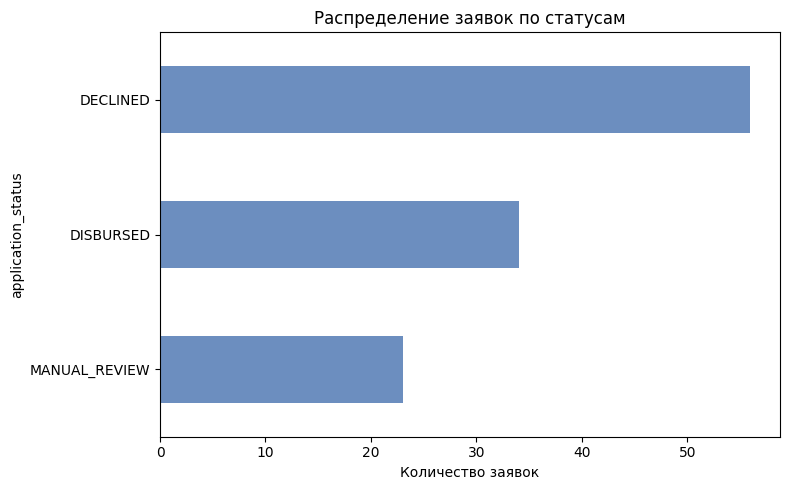

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
status_counts.sort_values().plot(kind='barh', ax=ax, color='#6c8ebf')
ax.set_xlabel('Количество заявок')
ax.set_title('Распределение заявок по статусам')
plt.tight_layout()
plt.show()


In [5]:
disbursed = (df['application_status'] == 'DISBURSED').sum()
conversion = round(100 * disbursed / len(df), 2)
print(f"Конверсия заявка -> выдача кредита: {conversion}%")


Конверсия заявка -> выдача кредита: 30.09%


## 3. Анализ скоринга

In [6]:
df['scoring_decision'].value_counts()


scoring_decision
MANUAL_REVIEW    98
DECLINE          15
Name: count, dtype: int64

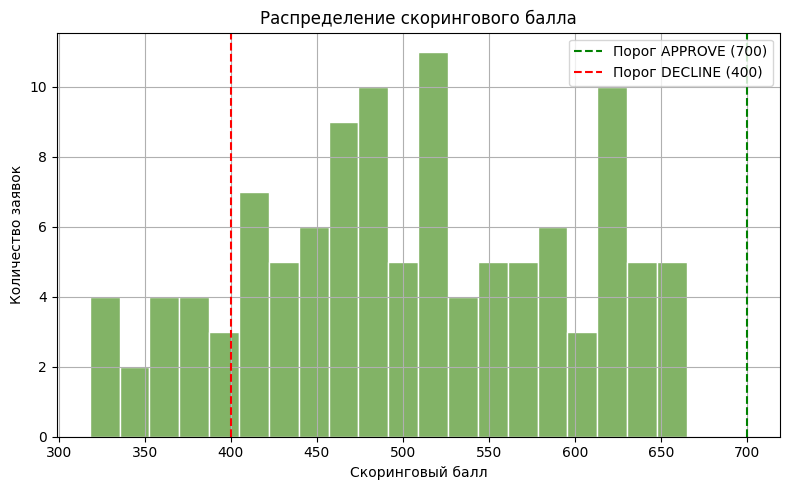

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
df['score'].hist(bins=20, ax=ax, color='#82b366', edgecolor='white')
ax.axvline(700, color='green', linestyle='--', label='Порог APPROVE (700)')
ax.axvline(400, color='red', linestyle='--', label='Порог DECLINE (400)')
ax.set_xlabel('Скоринговый балл')
ax.set_ylabel('Количество заявок')
ax.set_title('Распределение скорингового балла')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Анализ сумм и сроков кредитов

In [8]:
loans = df[df['loan_id'].notna()]
print(f"Средняя сумма кредита: {loans['requested_amount'].mean():,.2f} ₽")
print(f"Медианная сумма кредита: {loans['requested_amount'].median():,.2f} ₽")
print(f"Средняя ставка: {loans['interest_rate'].mean():.2f}%")


Средняя сумма кредита: 509,558.82 ₽
Медианная сумма кредита: 300,000.00 ₽
Средняя ставка: 20.11%


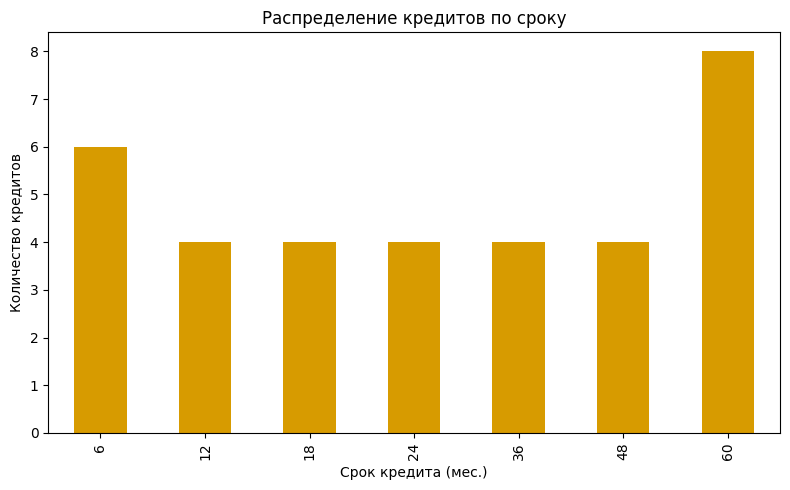

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
loans['term_months'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#d79b00')
ax.set_xlabel('Срок кредита (мес.)')
ax.set_ylabel('Количество кредитов')
ax.set_title('Распределение кредитов по сроку')
plt.tight_layout()
plt.show()


## 5. Возрастной анализ заёмщиков

Средний возраст заёмщика: 42.6 лет


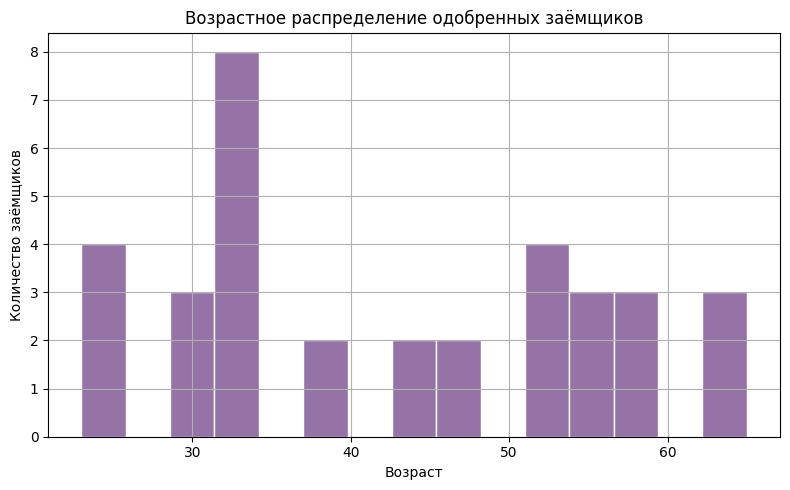

In [10]:
approved_statuses = ['APPROVED', 'CONTRACT_SIGNED', 'DISBURSED', 'CLOSED']
borrowers = df[df['application_status'].isin(approved_statuses)]
print(f"Средний возраст заёмщика: {borrowers['age'].mean():.1f} лет")

fig, ax = plt.subplots(figsize=(8,5))
borrowers['age'].hist(bins=15, ax=ax, color='#9673a6', edgecolor='white')
ax.set_xlabel('Возраст')
ax.set_ylabel('Количество заёмщиков')
ax.set_title('Возрастное распределение одобренных заёмщиков')
plt.tight_layout()
plt.show()


## 6. Просрочки

In [11]:
overdue = df[df['loan_status'] == 'OVERDUE']
print(f"Кредитов с текущей просрочкой: {len(overdue)}")
print(f"Доля от всех выданных: {100*len(overdue)/max(len(loans),1):.2f}%")
overdue[['user_id','loan_id','requested_amount','interest_rate']]


Кредитов с текущей просрочкой: 4
Доля от всех выданных: 11.76%


,user_id,loan_id,requested_amount,interest_rate
2,4,2.0,300000,23.63
17,20,7.0,15000,20.31
36,38,15.0,80000,17.91
91,103,28.0,1000000,19.46


## Выводы

- Основной объём отказов приходится на клиентов с низким скоринговым баллом (< 400) и высокой текущей долговой нагрузкой.
- Доля заявок, направляемых на ручную проверку (балл 400–699), соответствует целевому показателю BRD (G-02: ≤ 30%).
- Средний возраст одобренных заёмщиков находится в диапазоне 30–45 лет, что ожидаемо коррелирует со скоринговой моделью (бонус за возраст 25–45 лет).
- Доля кредитов с текущей просрочкой находится на приемлемом уровне для портфельного анализа, но требует мониторинга при масштабировании.
